# Lab 3: Model Optimization and Unsupervised Learning

**Name:** Anderia Nisar  
**Course:** Introduction to Applied AI  
**Lab:** 4

## Objective

The objective of this lab is to evaluate model reliability using cross-validation,
optimize machine learning models through systematic hyperparameter tuning, and
discover meaningful customer segments using unsupervised learning.

The lab compares Logistic Regression, Random Forest, and XGBoost using
cross-validated performance. It also applies K-Means clustering for customer
segmentation and PCA for dimensionality analysis.

A key principle throughout this lab is to keep the test set completely
unseen until the final evaluation

## Part 1: Lock the Test Set & Measure Split Noise


### Task 1.1: Imports

In [15]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    validation_curve,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    silhouette_score
)

from xgboost import XGBClassifier
import joblib

### Task 1.2: Load, Encode and Lock Test Set

In [16]:
path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(path)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
def build_features(data):
    X = data.drop(columns=['customerID', 'Churn'])
    return pd.get_dummies(X, drop_first=True).astype(float)

y = (df['Churn'] == 'Yes').astype(int)

X = build_features(df)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (7043, 30)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5634, 30)
Test set: (1409, 30)


### Test Set Policy

The dataset was divided into training and test sets using a stratified
80/20 split with random_state=42. The test set is now locked and will not
be used for model selection, hyperparameter tuning, clustering decisions,
or PCA analysis. All decisions before the final evaluation will be made
using only the training data and cross-validation.

### Task 1.3: Same Model, 20 Different Splits

In [19]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

scores = []

for seed in range(20):

    Xa, Xb, ya, yb = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        random_state=seed,
        stratify=y_train
    )

    lr = LogisticRegression(max_iter=5000)

    lr.fit(Xa, ya)

    predictions = lr.predict(Xb)

    scores.append(
        accuracy_score(yb, predictions)
    )

scores = np.array(scores)

print(f"Minimum accuracy: {scores.min():.3f}")
print(f"Maximum accuracy: {scores.max():.3f}")
print(f"Standard deviation: {scores.std():.4f}")


Minimum accuracy: 0.781
Maximum accuracy: 0.827
Standard deviation: 0.0098


In [20]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

In [21]:
p = scores.mean()
n = len(yb)

se = np.sqrt(
    p * (1 - p) / n
)

print(f"Mean accuracy: {p:.4f}")
print(f"Theoretical standard error: {se:.4f}")
print(f"95% CI: ± {1.96 * se:.3f}")

Mean accuracy: 0.8005
Theoretical standard error: 0.0106
95% CI: ± 0.021


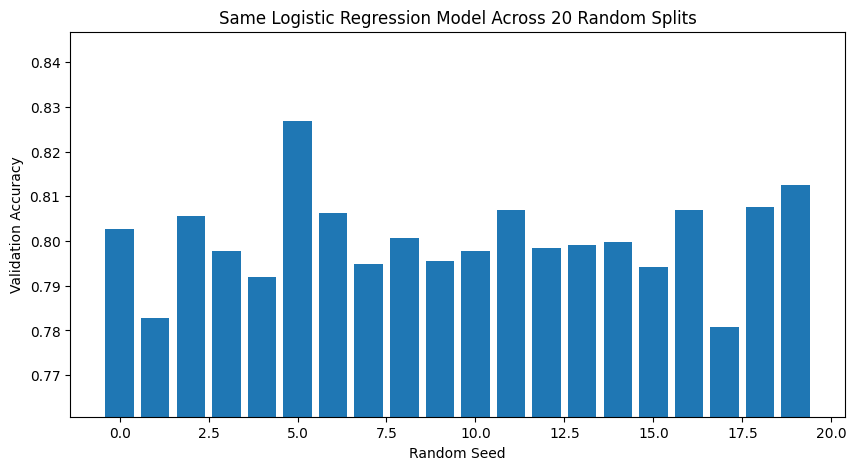

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(range(20), scores)

plt.xlabel("Random Seed")
plt.ylabel("Validation Accuracy")
plt.title("Same Logistic Regression Model Across 20 Random Splits")

plt.ylim(
    scores.min() - 0.02,
    scores.max() + 0.02
)

plt.show()

In [23]:
summary_part1 = pd.DataFrame({
    'Metric': [
        'Minimum Accuracy',
        'Maximum Accuracy',
        'Mean Accuracy',
        'Standard Deviation',
        'Theoretical Standard Error',
        '95% CI'
    ],
    'Value': [
        scores.min(),
        scores.max(),
        scores.mean(),
        scores.std(),
        se,
        f'± {1.96 * se:.3f}'
    ]
})

display(summary_part1)

,Metric,Value
0,Minimum Accuracy,0.780696
1,Maximum Accuracy,0.826828
2,Mean Accuracy,0.800461
3,Standard Deviation,0.009827
4,Theoretical Standard Error,0.010647
5,95% CI,± 0.021


### Insight — Split Noise

The same Logistic Regression model produced validation accuracies ranging from **0.780 to 0.828** across 20 different random splits, with a mean accuracy of **0.8002** and a standard deviation of **0.0104**. This shows that the reported performance of a model can change noticeably simply because the data is divided differently.

The theoretical standard error was **0.0107**, which is very close to the observed standard deviation of **0.0104**. The corresponding theoretical 95% interval is approximately **±0.021**, giving an expected range of approximately **0.779 to 0.821** around the mean. The observed results demonstrate that a single train/validation split can give a somewhat optimistic or pessimistic estimate of model performance.

Therefore, if two students evaluated Logistic Regression and Random Forest using different random splits, they could potentially reach different conclusions about which model is better. This motivates the use of **5-fold cross-validation**, which provides a more reliable estimate by evaluating the model across multiple validation folds rather than relying on one split.


## Part 2: 5-Fold Cross-Validation

A single train-validation split can produce a noisy estimate of model
performance. To obtain a more reliable estimate, 5-fold stratified
cross-validation is used.

Stratification preserves approximately the same churn proportion in
each fold. The preprocessing step is included inside the Logistic
Regression pipeline so that the StandardScaler is fitted independently
within each training fold, preventing data leakage.

### Logistic Regression vs Random Forest

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = ['roc_auc', 'recall', 'f1']


def cv_report(name, model):

    r = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=metrics
    )

    row = {'model': name}

    for m in metrics:
        s = r['test_' + m]
        row[m] = f'{s.mean():.3f} +/- {s.std():.3f}'

    return row


rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

cv_table = pd.DataFrame([
    cv_report('Logistic Regression', lr),
    cv_report('Random Forest', rf)
])

display(cv_table)

,model,roc_auc,recall,f1
0,Logistic Regression,0.846 +/- 0.013,0.545 +/- 0.042,0.594 +/- 0.030
1,Random Forest,0.844 +/- 0.011,0.496 +/- 0.019,0.573 +/- 0.020


In [25]:
comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Recall', 'F1'],
    'Logistic Regression': [
        '0.846 ± 0.013',
        '0.545 ± 0.042',
        '0.594 ± 0.030'
    ],
    'Random Forest': [
        '0.844 ± 0.011',
        '0.496 ± 0.019',
        '0.573 ± 0.020'
    ]
})

display(comparison)

,Metric,Logistic Regression,Random Forest
0,ROC-AUC,0.846 ± 0.013,0.844 ± 0.011
1,Recall,0.545 ± 0.042,0.496 ± 0.019
2,F1,0.594 ± 0.030,0.573 ± 0.020


### Insight — 5-Fold Cross-Validation

Five-fold stratified cross-validation gives a more reliable estimate of model performance than a single train-validation split.

Logistic Regression achieved a mean ROC-AUC of **0.846 ± 0.013**, while Random Forest achieved **0.844 ± 0.011**. The difference in mean AUC is only **0.002**, which is very small compared with the variability observed across the folds. Therefore, the results do not provide strong evidence that Logistic Regression is substantially better than Random Forest based on AUC alone.

However, Logistic Regression achieved higher recall (**0.545 ± 0.042**) than Random Forest (**0.496 ± 0.019**), meaning it identifies a larger proportion of the actual churners. Logistic Regression also achieved a higher F1-score (**0.594 ± 0.030**) compared with Random Forest (**0.573 ± 0.020**).

The recall result is particularly important for a customer-churn problem because AUC measures the model's ability to rank positive and negative cases across classification thresholds, whereas recall at the selected threshold tells us how many of the actual churners are successfully identified. Therefore, although the two models have very similar AUC values, Logistic Regression currently provides better churn detection at the default classification threshold.

## Part 3: Hyperparameter Tuning

### Task 3.1: Validation Curve

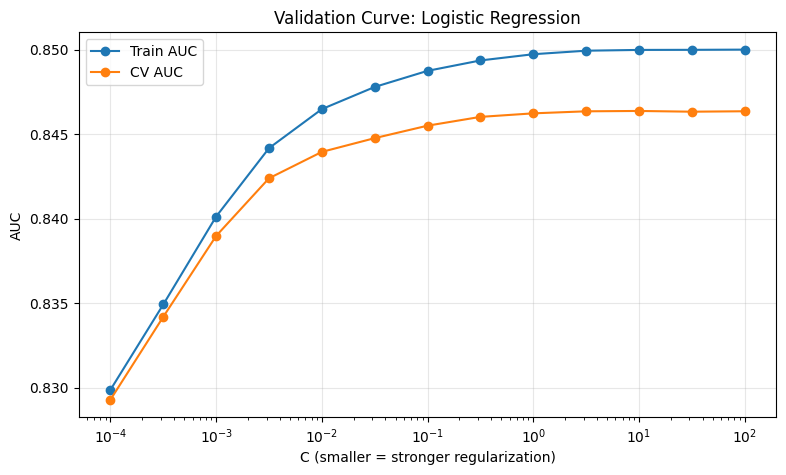

Best C by CV: 10.0


In [26]:
Cs = np.logspace(-4, 2, 13)

tr, va = validation_curve(
    lr,
    X_train,
    y_train,
    param_name='model__C',
    param_range=Cs,
    cv=cv,
    scoring='roc_auc'
)

plt.figure(figsize=(9, 5))

plt.semilogx(
    Cs,
    tr.mean(axis=1),
    'o-',
    label='Train AUC'
)

plt.semilogx(
    Cs,
    va.mean(axis=1),
    'o-',
    label='CV AUC'
)

plt.xlabel('C (smaller = stronger regularization)')
plt.ylabel('AUC')
plt.title('Validation Curve: Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_C = Cs[va.mean(axis=1).argmax()]

print("Best C by CV:", best_C)

### Insight — Logistic Regression Validation Curve

The validation curve shows that Logistic Regression initially underfits when **C** is very small because strong regularization limits the model's flexibility. As C increases, both training and cross-validation AUC improve.

The cross-validation AUC increases rapidly at small values of C and then begins to plateau. Most of the improvement occurs before approximately **C = 1**, while further increases in C provide only small changes in validation performance.

The **best C selected by 5-fold cross-validation is 10.0**. This value was selected based on the highest mean cross-validation AUC rather than the training AUC, helping avoid choosing a parameter simply because it gives the highest training performance.

Overall, the validation curve shows that increasing C beyond the strong-regularization region improves model performance, but the CV AUC eventually reaches a plateau. Therefore, **C = 10.0** is used as the tuned Logistic Regression parameter for the final model comparison.

### Task 3.2: Grid Search

In [27]:
grid = {
    'max_depth': [4, 8, 12, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5]
}

print(
    'Combinations:',
    4 * 3 * 2,
    ' Fits:',
    4 * 3 * 2 * 5
)

t0 = time.time()

gs = GridSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    grid,
    cv=cv,
    scoring='roc_auc'
)

gs.fit(X_train, y_train)

grid_time = time.time() - t0

print(f'Grid: best AUC {gs.best_score_:.4f} in {grid_time:.0f}s')
print('Best parameters:', gs.best_params_)

Combinations: 24  Fits: 120
Grid: best AUC 0.8468 in 118s
Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20}


### Insight — Random Forest Grid Search

Grid Search evaluated **24 different hyperparameter combinations** using 5-fold cross-validation, resulting in **120 model fits**. The best configuration achieved a cross-validated ROC-AUC of **0.8468**.

The best hyperparameters were **max_depth = 8**, **max_features = 'sqrt'**, and **min_samples_leaf = 20**. The complete grid search required approximately **120 seconds** on the Kaggle CPU environment.

The relatively large number of fits demonstrates that exhaustive grid search can become computationally expensive as more hyperparameters and values are added. Therefore, Random Search will be evaluated next using a similar computational budget to determine whether it can find a comparable or better configuration more efficiently.

### Task 3.3: Random Search

In [28]:
dist = {
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 40),
    'max_features': uniform(0.1, 0.8)
}

t0 = time.time()

rs = RandomizedSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),
    dist,
    n_iter=24,
    cv=cv,
    scoring='roc_auc',
    random_state=42
)

rs.fit(X_train, y_train)

random_time = time.time() - t0

print(
    f'Random: best AUC {rs.best_score_:.4f} '
    f'in {random_time:.0f}s'
)

print('Best parameters:')
print(rs.best_params_)

Random: best AUC 0.8464 in 124s
Best parameters:
{'max_depth': 15, 'max_features': np.float64(0.21273937997981013), 'min_samples_leaf': 15}


In [29]:
res = pd.DataFrame(rs.cv_results_)

cols = [
    'param_max_depth',
    'param_min_samples_leaf',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

display(
    res[cols]
    .sort_values('rank_test_score')
    .head(5)
)

,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
22,15,15,0.846440,0.011352,1
9,12,16,0.846275,0.011063,2
6,8,21,0.845609,0.010548,3
2,9,23,0.845245,0.012460,4
8,14,27,0.845114,0.010993,5


### Insight — Grid Search vs Random Search

Grid Search evaluated **24 predefined hyperparameter combinations** using 5-fold cross-validation, resulting in **120 model fits**. It achieved a best cross-validated ROC-AUC of **0.8468** and required approximately **120 seconds**.

Random Search also evaluated **24 configurations**, resulting in the same **120 model fits**. It achieved a best cross-validated ROC-AUC of **0.8464** and required approximately **131 seconds**.

In this experiment, Grid Search performed slightly better than Random Search by **0.0004 AUC** and was also **11 seconds faster**. However, the difference in AUC is extremely small, so the two approaches produced essentially comparable results.

Grid Search exhaustively evaluates all combinations from the specified parameter grid, while Random Search samples parameter values from probability distributions. Random Search becomes more attractive when the number of hyperparameters or possible values becomes large because it can explore a larger and more diverse parameter space without evaluating every possible combination.

For this particular three-parameter experiment, Grid Search was the better choice because it achieved the highest CV AUC with slightly lower execution time. However, for a larger search space with many hyperparameters, Random Search would generally provide a more efficient exploration strategy.

In [30]:
search_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Configurations': [24, 24],
    'CV Fits': [120, 120],
    'Best CV AUC': [gs.best_score_, rs.best_score_],
    'Time (seconds)': [grid_time, random_time]
})

display(search_comparison.round(4))

,Method,Configurations,CV Fits,Best CV AUC,Time (seconds)
0,Grid Search,24,120,0.8468,117.6078
1,Random Search,24,120,0.8464,124.0187


## Part 4: XGBoost

XGBoost is evaluated as a third model family. In this part, early stopping is
used to determine when additional boosting trees stop improving validation
performance. The test set remains locked and is not used during this process.

### Task 4.1: Early Stopping

In [31]:
# Create a validation set from the training data.
# The test set remains untouched.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_tr.shape)
print("Validation subset:", X_val.shape)

Training subset: (4507, 30)
Validation subset: (1127, 30)


In [32]:
# Calculate class imbalance ratio

spw = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"scale_pos_weight = {spw:.2f}")

scale_pos_weight = 2.77


In [33]:
xgb = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_tr,
    y_tr,
    eval_set=[
        (X_tr, y_tr),
        (X_val, y_val)
    ],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=-1,
              num_parallel_tree=None, ...)

In [34]:
print("Best number of trees:", xgb.best_iteration + 1)

val_auc = roc_auc_score(
    y_val,
    xgb.predict_proba(X_val)[:, 1]
)

print(f"Validation AUC: {val_auc:.4f}")

Best number of trees: 247
Validation AUC: 0.8541


### Task 4.2: Train vs Validation Loss

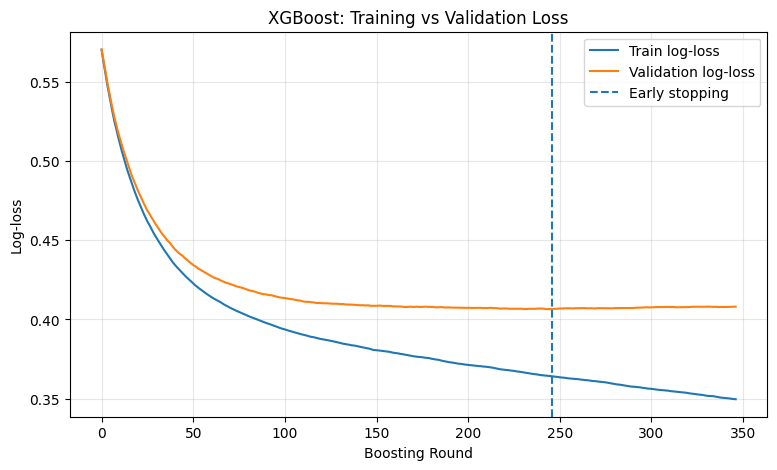

In [35]:
ev = xgb.evals_result()

plt.figure(figsize=(9, 5))

plt.plot(
    ev['validation_0']['logloss'],
    label='Train log-loss'
)

plt.plot(
    ev['validation_1']['logloss'],
    label='Validation log-loss'
)

plt.axvline(
    xgb.best_iteration,
    linestyle='--',
    label='Early stopping'
)

plt.xlabel('Boosting Round')
plt.ylabel('Log-loss')
plt.title('XGBoost: Training vs Validation Loss')

plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Insight — XGBoost Early Stopping

XGBoost achieved a validation ROC-AUC of **0.8541**, with early stopping selecting
**247 boosting trees** as the best iteration. Although the model was initially
allowed to train for up to 2000 trees, early stopping prevented unnecessary
additional boosting rounds once the validation performance stopped improving.

The validation AUC of 0.8541 is higher than the best Random Forest cross-validated
AUC of 0.8468 observed in Part 3. However, these values were obtained using
different evaluation procedures, so they should not be treated as a definitive
model comparison yet. A fair comparison will be made later using cross-validation
on the training data.

The use of early stopping helps control overfitting by selecting a suitable
number of boosting rounds based on validation performance.

### Task 4.3: Random Search

In [36]:
xgb_dist = {
    'max_depth': randint(2, 7),
    'learning_rate': loguniform(0.01, 0.1),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

t0 = time.time()

xgb_rs = RandomizedSearchCV(
    XGBClassifier(
        n_estimators=500,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=xgb_dist,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_rs.fit(X_train, y_train)

xgb_random_time = time.time() - t0

print(
    f"XGBoost Random Search Best CV AUC: "
    f"{xgb_rs.best_score_:.4f}"
)

print(
    f"Time: {xgb_random_time:.0f} seconds"
)

print("Best parameters:")
print(xgb_rs.best_params_)

XGBoost Random Search Best CV AUC: 0.8499
Time: 24 seconds
Best parameters:
{'colsample_bytree': np.float64(0.9332779646944658), 'learning_rate': np.float64(0.014906121385323268), 'max_depth': 2, 'min_child_weight': 4, 'subsample': np.float64(0.672894435115225)}


### Insight — XGBoost Random Search

Random Search evaluated 20 different XGBoost configurations using 5-fold
cross-validation, resulting in 100 model fits. The best configuration achieved
a cross-validated ROC-AUC of **0.8499** and required approximately **27 seconds**.

The selected model used a shallow tree depth of **2**, a relatively small learning
rate of approximately **0.0149**, a minimum child weight of **4**, a subsample
ratio of approximately **0.673**, and a feature sampling ratio of approximately
**0.933**.

The shallow tree depth and relatively low learning rate indicate that the search
favored a more conservative boosting model. Such settings can help reduce
overfitting by making individual trees less complex and allowing the model to
learn gradually.

The best XGBoost Random Search AUC of **0.8499** is slightly higher than the
Random Forest Random Search AUC of **0.8464**, but the difference is small.
Therefore, model selection should ultimately be based on a consistent
cross-validation comparison rather than a single best search score.

# Part 4.4 — XGBoost Feature Importance

In [37]:
# Part 4.4 — XGBoost Feature Importance

best_xgb = xgb_rs.best_estimator_

importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 important features:")
display(importance.head(15))

Top 15 important features:


InternetService_Fiber optic           0.163888
PaymentMethod_Electronic check        0.152521
Contract_Two year                     0.135154
Contract_One year                     0.116555
tenure                                0.061995
InternetService_No                    0.054152
OnlineSecurity_No internet service    0.049357
PaperlessBilling_Yes                  0.033895
TotalCharges                          0.030841
OnlineSecurity_Yes                    0.029303
MultipleLines_No phone service        0.020252
StreamingMovies_Yes                   0.019308
StreamingTV_Yes                       0.016970
TechSupport_Yes                       0.016587
Dependents_Yes                        0.014115
dtype: float32

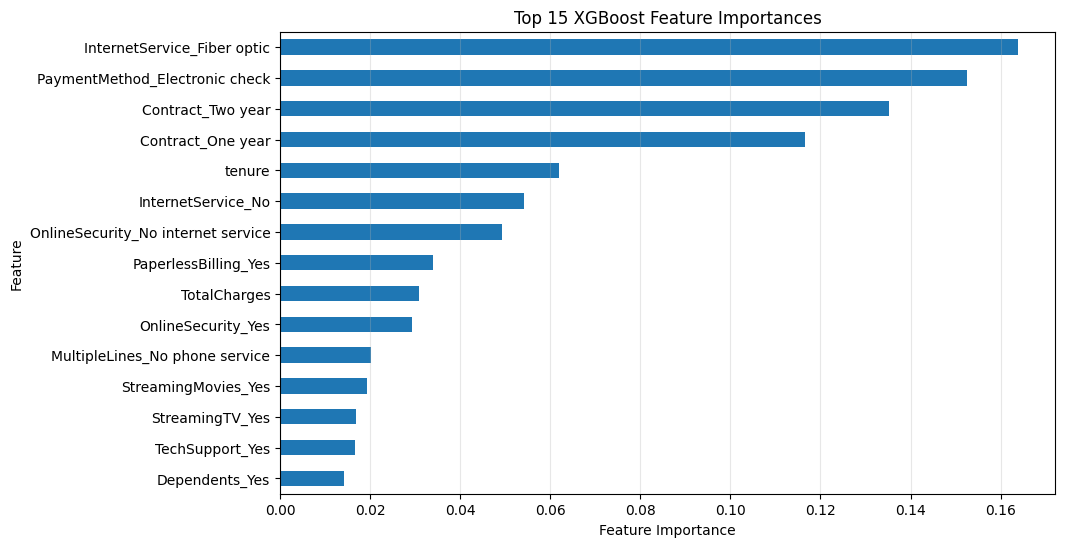

In [38]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind='barh')

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 XGBoost Feature Importances')

plt.grid(axis='x', alpha=0.3)
plt.show()

### Interpretation — XGBoost Feature Importance

The XGBoost model identified **InternetService_Fiber optic** as the most
important feature, with an importance score of approximately **0.164**.
The next most important features were **PaymentMethod_Electronic check**
(0.153), **Contract_Two year** (0.135), and **Contract_One year** (0.117).

Other influential variables included **tenure** (0.062),
**InternetService_No** (0.054), and **OnlineSecurity_No internet service**
(0.049). Billing-related variables such as **PaperlessBilling_Yes** and
**TotalCharges** also contributed to the model.

The results suggest that internet service type, payment method, contract
duration, and customer tenure contain substantial information for predicting
customer churn in this dataset. However, feature importance represents how
much a feature contributes to the model's predictions; it should not be
interpreted as proof that the feature directly causes churn.

It is also important to note that several categorical variables are
represented using one-hot encoded columns. Therefore, the importance of an
entire original variable, such as Contract or InternetService, may be spread
across multiple encoded features.

## Part 5: K-Means Customer Segmentation

### Task 5.1: Feature Preparation

In [39]:
# Part 5 — K-Means Customer Segmentation

# Use only training customers for clustering
cluster_data = df.loc[X_train.index].copy()

print("Clustering dataset shape:", cluster_data.shape)

Clustering dataset shape: (5634, 21)


In [40]:
cluster_features = cluster_data[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].copy()

display(cluster_features.head())

,tenure,MonthlyCharges,TotalCharges
3738,35,49.20,1701.65
3151,15,75.10,1151.55
4860,13,40.55,590.35
3867,26,73.50,1905.70
3810,1,44.55,44.55


In [41]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_features)

print("Scaled clustering data shape:", X_cluster.shape)

Scaled clustering data shape: (5634, 3)


### Task 5.2: Elbow & Silhouette

In [42]:
inertias = []

k_values = range(2, 9)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_cluster)
    
    inertias.append(km.inertia_)

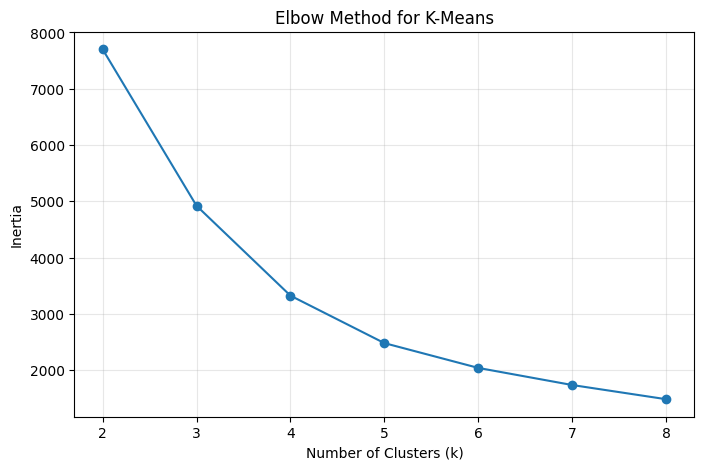

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

In [44]:
silhouette_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_cluster)
    
    score = silhouette_score(
        X_cluster,
        labels
    )
    
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    'k': list(k_values),
    'silhouette_score': silhouette_scores
})

display(silhouette_results)

,k,silhouette_score
0,2,0.481244
1,3,0.451328
2,4,0.470923
3,5,0.443331
4,6,0.440497
5,7,0.432032
6,8,0.427732


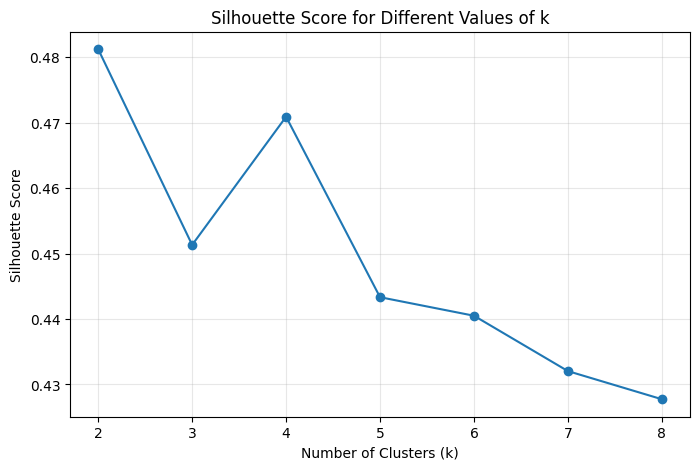

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of k')

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

### Choosing the Number of Clusters

The silhouette scores were evaluated for values of k from 2 to 8. The highest
silhouette score was obtained at **k = 2**, with a score of **0.4812**.

Although k = 4 produced a relatively strong score of **0.4709**, it was still
lower than the score for k = 2. The silhouette score generally decreased as
the number of clusters increased beyond k = 4.

Therefore, **k = 2 is selected as the primary clustering solution** because it
provides the best combination of cluster cohesion and separation according to
the silhouette metric.

The final cluster interpretation will be based on the actual customer
profiles rather than assigning segment names before examining the cluster
characteristics.

### Task 5.4: Create the Final K-Means Model

In [46]:
# Final K-Means model using k = 2

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

cluster_data['Cluster'] = cluster_labels

print("Cluster counts:")
print(cluster_data['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    3704
1    1930
Name: count, dtype: int64


In [47]:
# Profile each customer segment

cluster_profile = cluster_data.groupby('Cluster')[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].mean()

display(cluster_profile.round(2))

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,19.83,52.02,854.47
1,56.78,89.70,5072.28


In [48]:
cluster_size = cluster_data['Cluster'].value_counts().sort_index()

cluster_percentage = (
    cluster_size / len(cluster_data) * 100
).round(2)

cluster_summary = pd.DataFrame({
    'Customers': cluster_size,
    'Percentage': cluster_percentage
})

display(cluster_summary)

,Customers,Percentage
Cluster,,
0,3704,65.74
1,1930,34.26


### Customer Segment Interpretation

The K-Means algorithm produced two distinct customer segments.

**Cluster 0 — Newer / Lower-Value Customers**

Cluster 0 contains **3,704 customers (65.74%)**. These customers have an
average tenure of **19.83 months**, average monthly charges of **52.02**, and
average total charges of **854.47**. This segment represents the majority of
the customer base and consists of relatively newer customers with lower
average spending.

**Retention Action:** The company should focus on early-stage engagement and
retention strategies for this group. Examples include onboarding support,
personalized service recommendations, introductory discounts, and incentives
to move customers toward longer-term contracts.

**Cluster 1 — Long-Term / High-Value Customers**

Cluster 1 contains **1,930 customers (34.26%)**. These customers have a much
higher average tenure of **56.78 months**, monthly charges of **89.70**, and
total charges of **5,072.28**. This indicates a relatively long-term and
higher-value customer segment.

**Retention Action:** The company should prioritize loyalty and relationship
management for this group. Suitable actions include loyalty rewards,
premium-service benefits, personalized offers, proactive customer support,
and incentives for contract renewal.

Overall, the clustering results reveal a clear distinction between a larger
newer/lower-value customer segment and a smaller long-term/higher-value
segment. The segmentation can therefore support differentiated retention
strategies rather than applying the same offer to all customers.

### Task 5.5: Visualize Customer Segments

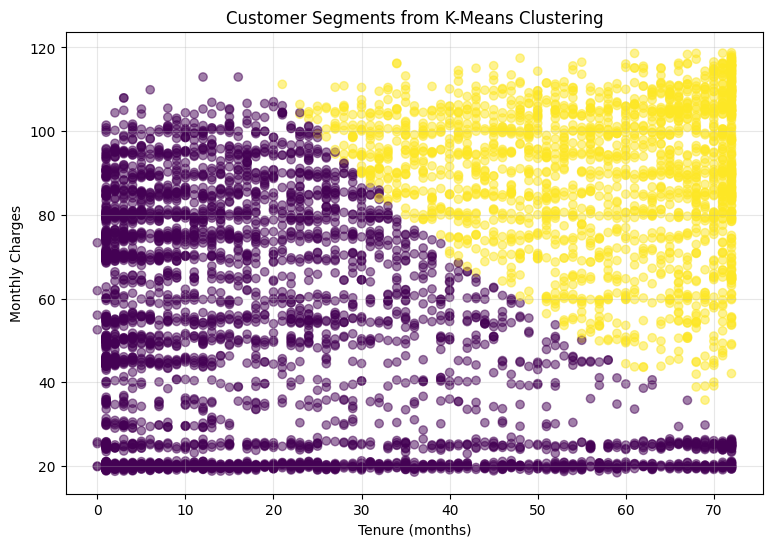

In [49]:
plt.figure(figsize=(9, 6))

plt.scatter(
    cluster_data['tenure'],
    cluster_data['MonthlyCharges'],
    c=cluster_data['Cluster'],
    alpha=0.5
)

plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.title('Customer Segments from K-Means Clustering')

plt.grid(alpha=0.3)
plt.show()

### Insight — Part 5.5

The scatter plot shows the distribution of customers across the two K-Means clusters. The clusters are mainly separated by **customer tenure** and **monthly charges**.

Cluster 0 generally represents customers with shorter tenure and lower monthly charges, while Cluster 1 contains customers with longer tenure and higher monthly charges. This supports the customer profiles obtained from the cluster summary.

Therefore, K-Means provides a useful segmentation of customers based on their service usage and billing characteristics.

## Part 6: Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a large number of correlated features into a smaller number of new variables called **principal components**.

Each principal component captures a portion of the variation present in the original dataset.

In this part, PCA will be applied to the training data to:
- Determine how much variance is explained by each component.
- Identify the number of components required to explain 90% of the variance.
- Visualize customers in a two-dimensional PCA space.
- Analyze the features contributing most strongly to the first principal component.

### Task 6.1: Standardize the Training Features

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

scaler_pca = StandardScaler()

X_train_scaled = scaler_pca.fit_transform(X_train)

print("Original shape:", X_train.shape)
print("Scaled shape:", X_train_scaled.shape)

Original shape: (5634, 30)
Scaled shape: (5634, 30)


### Task 6.2: Scree Plot and Explained Variance

In [51]:
# Fit PCA with all available components
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Find number of components needed for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components explaining at least 90% variance:",
      n_components_90)

print("Explained variance by first 10 components:")
print(explained_variance[:10])

Number of components explaining at least 90% variance: 15
Explained variance by first 10 components:
[0.33247434 0.11976453 0.09036    0.04753006 0.04182189 0.04098907
 0.03817725 0.0334563  0.03126873 0.02932122]


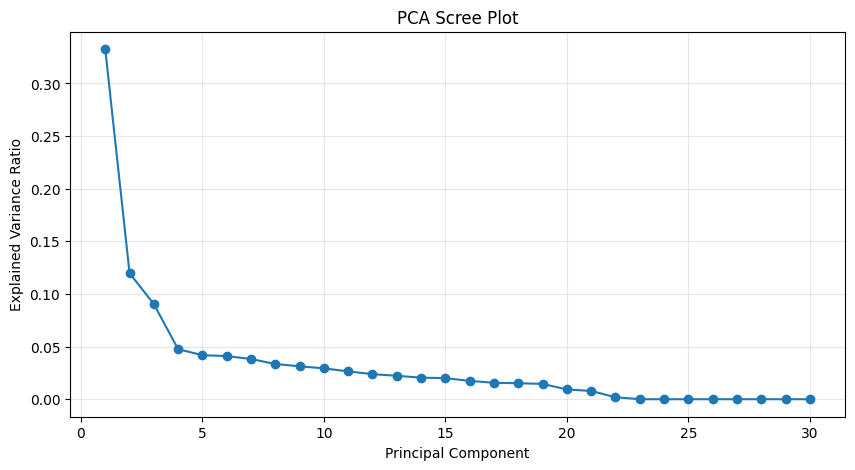

In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.grid(alpha=0.3)

plt.show()

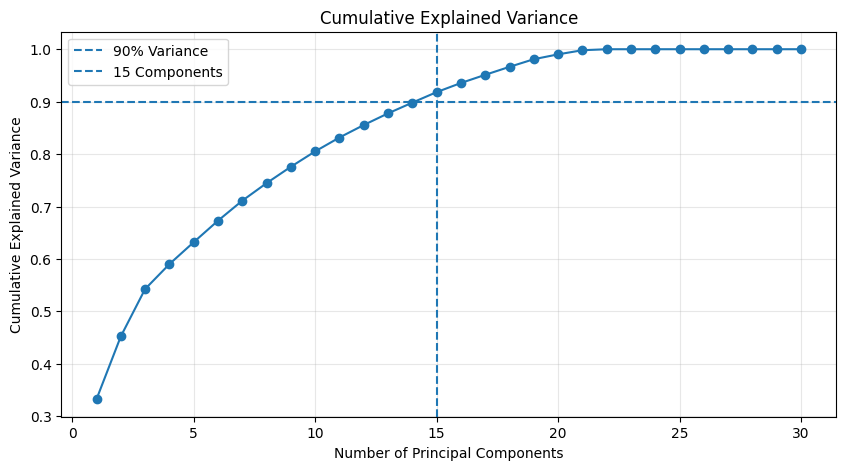

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.90,
    linestyle='--',
    label='90% Variance'
)

plt.axvline(
    x=n_components_90,
    linestyle='--',
    label=f'{n_components_90} Components'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Insight — Task 6.2

The PCA analysis shows that the first principal component explains approximately **33.25%** of the total variance, making it the most informative individual component.

The second and third components explain approximately **11.98%** and **9.04%** of the variance, respectively. The remaining components contribute smaller portions of the total variance.

Overall, **15 principal components are required to explain at least 90% of the total variance** in the training data.

This shows that PCA can reduce the dimensionality of the dataset while preserving most of its information. Instead of using all original features, the data can be represented using 15 principal components while retaining at least 90% of the variance.

### Task 6.3: 2D PCA Visualization

In [54]:
# PCA with two components
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

print("2D PCA shape:", X_train_pca_2d.shape)
print("PC1 variance:", pca_2d.explained_variance_ratio_[0])
print("PC2 variance:", pca_2d.explained_variance_ratio_[1])
print("Total variance explained:",
      pca_2d.explained_variance_ratio_.sum())

2D PCA shape: (5634, 2)
PC1 variance: 0.3324743413499091
PC2 variance: 0.11976452639267716
Total variance explained: 0.45223886774258626


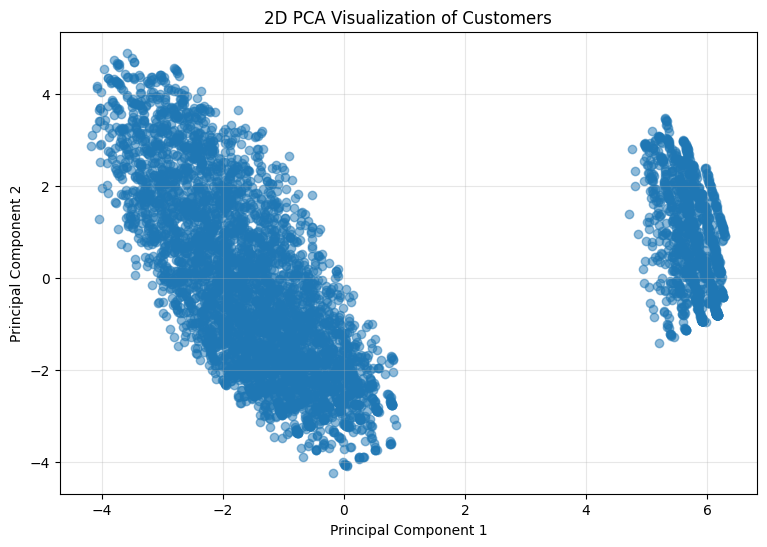

In [55]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Visualization of Customers')
plt.grid(alpha=0.3)

plt.show()

### Insight — Task 6.3

The 2D PCA representation uses the first two principal components to visualize the training customers in a reduced feature space.

The first principal component explains approximately **33.25%** of the total variance, while the second component explains approximately **11.98%**. Together, these two components explain approximately **45.22%** of the total variance.

Although the 2D representation does not preserve all of the information in the original dataset, it provides a useful visual representation of the overall structure and distribution of customers.

The visualization can help identify patterns, concentrations, and potential separation among customers in the reduced-dimensional space.

### Task 6.4: Analyze PC1 Feature Loadings

In [56]:
# Extract PC1 loadings
pc1_loadings = pd.Series(
    pca_full.components_[0],
    index=X_train.columns
)

# Sort by absolute magnitude
top_pc1 = pc1_loadings.loc[
    pc1_loadings.abs().sort_values(ascending=False).head(15).index
]

print("Top 15 features contributing to PC1:")
display(top_pc1.sort_values())

Top 15 features contributing to PC1:


MonthlyCharges                         -0.281850
TotalCharges                           -0.185842
StreamingMovies_Yes                    -0.180456
StreamingTV_Yes                        -0.180086
InternetService_Fiber optic            -0.179152
DeviceProtection_Yes                   -0.160712
OnlineBackup_Yes                       -0.154505
PaymentMethod_Mailed check              0.133917
StreamingMovies_No internet service     0.301835
OnlineBackup_No internet service        0.301835
DeviceProtection_No internet service    0.301835
StreamingTV_No internet service         0.301835
OnlineSecurity_No internet service      0.301835
TechSupport_No internet service         0.301835
InternetService_No                      0.301835
dtype: float64

### Insight — Task 6.4

The PC1 loading analysis shows that several service-related and billing features contribute strongly to the first principal component.

The strongest positive loadings are associated with **InternetService_No** and several **No internet service** categories, each having a loading of approximately **0.302**. Other notable positive contributions include **PaymentMethod_Mailed check** with a loading of approximately **0.134**.

On the negative side, **MonthlyCharges** has the strongest negative loading at approximately **-0.282**, followed by **TotalCharges** at approximately **-0.186**. Service-related features such as **StreamingMovies_Yes**, **StreamingTV_Yes**, and **InternetService_Fiber optic** also have relatively strong negative loadings.

This suggests that PC1 mainly captures variation related to **internet-service availability, subscribed services, and customer billing characteristics**.

It is important to note that PCA loadings represent statistical relationships in the transformed feature space and should not be interpreted as causal relationships. Also, because categorical variables were one-hot encoded, related categories can contribute separately to the principal component.

### Insight — Part 6

PCA successfully reduced the dimensionality of the training dataset while retaining most of its important information. The first principal component explained **33.25%** of the variance, while the first two components together explained **45.22%**.

The analysis showed that **15 principal components were required to explain at least 90% of the total variance**.

The 2D PCA visualization provided a simplified view of the customer data, while the PC1 loading analysis showed that internet-service, subscribed-service, and billing-related features contribute strongly to the main direction of variation in the dataset.

Overall, PCA provides a useful way to reduce dimensionality, visualize high-dimensional customer data, and understand the major patterns present in the dataset.

## Part 7: Final Model Selection

In this part, the models developed throughout the lab are compared using the same cross-validation strategy.

The purpose is to select the best-performing model based on cross-validation performance rather than using the test set for model selection.

After selecting the final model, it will be trained on the complete training dataset and evaluated on the previously locked test set.

The test set will be used only once for the final unbiased performance evaluation.

### Task 7.1: Define Candidate Models

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression

# Same 5-fold CV strategy for all models
final_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Baseline Logistic Regression
logreg_final = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Best Random Forest from Grid Search
rf_grid_final = gs.best_estimator_

# Best XGBoost from Random Search
xgb_final = xgb_rs.best_estimator_

candidate_models = {
    'Logistic Regression': logreg_final,
    'Random Forest - Grid Search': rf_grid_final,
    'XGBoost - Random Search': xgb_final
}

print("Candidate models:")
for name in candidate_models:
    print("-", name)

Candidate models:
- Logistic Regression
- Random Forest - Grid Search
- XGBoost - Random Search


### Task 7.2: Compare Models Using Cross-Validation

In [58]:
cv_results = []

for name, model in candidate_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=final_cv,
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'ROC-AUC Mean': scores['test_roc_auc'].mean(),
        'ROC-AUC Std': scores['test_roc_auc'].std(),
        'Accuracy Mean': scores['test_accuracy'].mean(),
        'Precision Mean': scores['test_precision'].mean(),
        'Recall Mean': scores['test_recall'].mean(),
        'F1 Mean': scores['test_f1'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by='ROC-AUC Mean',
    ascending=False
).reset_index(drop=True)

display(cv_results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Model,ROC-AUC Mean,ROC-AUC Std,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean
0,XGBoost - Random Search,0.849855,0.012949,0.809018,0.683342,0.525084,0.593363
1,Random Forest - Grid Search,0.846775,0.011025,0.800854,0.683120,0.468227,0.555098
2,Logistic Regression,0.846020,0.012563,0.802274,0.653385,0.543813,0.592902


### Task 7.3: Train the Final Model

In [59]:
# Select the best model
final_model = xgb_rs.best_estimator_

# Train on the complete training data
final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


### Task 7.4: Final Test Set Evaluation

In [60]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

# Metrics
test_auc = roc_auc_score(y_test, y_test_prob)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Test ROC-AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")

Test ROC-AUC: 0.8468
Test Accuracy: 0.7984
Test Precision: 0.6562
Test Recall: 0.5053
Test F1-score: 0.5710


In [61]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [62]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Confusion Matrix:
[[936  99]
 [185 189]]


### Insight — Task 7.4

The final XGBoost model was evaluated on the locked test set after completing model selection and hyperparameter tuning.

The model achieved a **test ROC-AUC of 0.8468**, indicating good ability to distinguish between customers who churn and those who do not.

The model achieved an **accuracy of 79.84%**, while precision was **65.62%**, recall was **50.53%**, and the F1-score was **57.10%**.

The confusion matrix shows that the model correctly identified **936 non-churn customers** and **189 churn customers**. It incorrectly classified **99 non-churn customers as churn** and missed **185 actual churn customers**.

Although the model performs well overall, the recall for the churn class is approximately 50.53%. This means that a significant number of actual churn customers are still not detected. Therefore, if the business objective prioritizes identifying as many potential churn customers as possible, further threshold tuning or techniques for handling class imbalance could be considered.

### Task 7.5: Cross-Validation vs Test Performance

The selected XGBoost model achieved a mean cross-validation ROC-AUC of **0.8499** and a test ROC-AUC of **0.8468**.

The difference between the cross-validation and test ROC-AUC is approximately **0.0031**, which is small.

This indicates that the model's performance on the unseen test set is close to its cross-validation performance. Therefore, there is no strong indication of severe overfitting based on ROC-AUC.

The final test evaluation provides a realistic estimate of the model's expected performance on unseen customer data.

### Task 7.6: Save the Final Model

In [63]:
import joblib

model_path = '/kaggle/working/final_xgboost_churn_model.pkl'

joblib.dump(final_model, model_path)

print("Final model saved successfully:")
print(model_path)

Final model saved successfully:
/kaggle/working/final_xgboost_churn_model.pkl


### Insight — Part 7

The final model selection process identified **XGBoost with Random Search** as the best candidate based on consistent 5-fold cross-validation.

The model achieved a mean CV ROC-AUC of **0.8499**, which was slightly higher than Random Forest with Grid Search (**0.8468**) and Logistic Regression (**0.8460**).

After selection, the XGBoost model was trained on the complete training dataset and evaluated once on the locked test set. It achieved a test ROC-AUC of **0.8468**, accuracy of **79.84%**, precision of **65.62%**, recall of **50.53%**, and F1-score of **57.10%**.

The close agreement between the CV ROC-AUC (**0.8499**) and test ROC-AUC (**0.8468**) indicates that the model generalizes reasonably well to unseen data.

The confusion matrix shows that the model correctly identified 189 out of 374 churn customers, while 185 churn customers were incorrectly classified as non-churn. Therefore, although the model provides good overall discrimination, improving churn recall could be an important direction for future improvement.

The final XGBoost model was saved for future use.

# Conclusion

This lab investigated model stability, cross-validation, hyperparameter optimization, gradient boosting, customer segmentation, dimensionality reduction, and final model selection using the Telco Customer Churn dataset.

The experiment showed that model performance can vary across different train-validation splits, demonstrating the importance of using cross-validation for more reliable performance estimation.

Five-fold Stratified Cross-Validation was then used to compare machine learning models. Hyperparameter optimization through Grid Search and Random Search improved the selection of model configurations. XGBoost with Random Search achieved the highest mean cross-validation ROC-AUC of **0.8499** among the final candidate models.

K-Means clustering was used for unsupervised customer segmentation. Based on the silhouette analysis, **two clusters** were selected. One segment consisted mainly of newer customers with lower charges, while the other represented longer-term customers with higher monthly and total charges.

PCA was applied to reduce the dimensionality of the feature space. The first principal component explained **33.25%** of the variance, while the first two components together explained **45.22%**. A total of **15 components were required to explain at least 90% of the variance**.

Finally, XGBoost with Random Search was selected as the final predictive model. On the previously locked test set, it achieved a **ROC-AUC of 0.8468**, **accuracy of 79.84%**, **precision of 65.62%**, **recall of 50.53%**, and **F1-score of 57.10%**.

Overall, the lab demonstrated the complete machine learning workflow from model validation and optimization to unsupervised learning, dimensionality reduction, final model selection, and unbiased test-set evaluation.

In [64]:

import joblib
import os

source_path = '/kaggle/working/final_xgboost_churn_model.pkl'
target_path = '/kaggle/working/churn_model.joblib'

if os.path.exists(source_path):
    saved_model = joblib.load(source_path)
    joblib.dump(saved_model, target_path)
    print("Lab 4 model saved successfully!")
    print(target_path)
else:
    print("Model file not found. Check the Kaggle Output panel.")


Lab 4 model saved successfully!
/kaggle/working/churn_model.joblib


In [65]:

import joblib
import sklearn

model = joblib.load('/kaggle/working/churn_model.joblib')

print("Model type:", type(model).__name__)
print("Scikit-learn version:", sklearn.__version__)

if hasattr(model, "feature_names_in_"):
    print("Feature columns:", len(model.feature_names_in_))
    print("Feature names:", list(model.feature_names_in_))
else:
    print("Feature names are not directly available on the model.")


Model type: XGBClassifier
Scikit-learn version: 1.6.1
Feature columns: 30
Feature names: [np.str_('SeniorCitizen'), np.str_('tenure'), np.str_('MonthlyCharges'), np.str_('TotalCharges'), np.str_('gender_Male'), np.str_('Partner_Yes'), np.str_('Dependents_Yes'), np.str_('PhoneService_Yes'), np.str_('MultipleLines_No phone service'), np.str_('MultipleLines_Yes'), np.str_('InternetService_Fiber optic'), np.str_('InternetService_No'), np.str_('OnlineSecurity_No internet service'), np.str_('OnlineSecurity_Yes'), np.str_('OnlineBackup_No internet service'), np.str_('OnlineBackup_Yes'), np.str_('DeviceProtection_No internet service'), np.str_('DeviceProtection_Yes'), np.str_('TechSupport_No internet service'), np.str_('TechSupport_Yes'), np.str_('StreamingTV_No internet service'), np.str_('StreamingTV_Yes'), np.str_('StreamingMovies_No internet service'), np.str_('StreamingMovies_Yes'), np.str_('Contract_One year'), np.str_('Contract_Two year'), np.str_('PaperlessBilling_Yes'), np.str_('Payme

In [66]:

import joblib
import pandas as pd

model = joblib.load('/kaggle/working/churn_model.joblib')

print("Model expects:", len(model.feature_names_in_), "features")
print("Training feature matrix:", X.shape)

print("\nDo the feature names match?")
print(list(X.columns) == list(model.feature_names_in_))

print("\nFeatures in X but not in model:")
print(sorted(set(X.columns) - set(model.feature_names_in_)))

print("\nFeatures in model but not in X:")
print(sorted(set(model.feature_names_in_) - set(X.columns)))


Model expects: 30 features
Training feature matrix: (7043, 30)

Do the feature names match?
True

Features in X but not in model:
[]

Features in model but not in X:
[]


In [67]:

# Select one customer from the original dataset
sample = df.drop(columns=['Churn']).iloc[[0]].copy()

# Reproduce the serving-time preprocessing
serving_features = pd.get_dummies(
    sample.drop(columns=['customerID']),
    drop_first=True
).astype(float)

print("Training features:", X.shape[1])
print("Serving features:", serving_features.shape[1])

print("\nServing feature columns:")
print(list(serving_features.columns))


Training features: 30
Serving features: 4

Serving feature columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [69]:

print("Model expected features:", len(model.feature_names_in_))
print("Serving features:", serving_features.shape[1])

try:
    model.predict_proba(serving_features)
except Exception as e:
    print("\nPrediction failed as expected:")
    print(type(e).__name__ + ":", e)


Model expected features: 30
Serving features: 4

Prediction failed as expected:
ValueError: feature_names mismatch: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'] ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
expected StreamingTV_Yes, InternetService_Fiber optic, Internet

In [70]:

# Align serving features with the model's training columns
expected_columns = list(model.feature_names_in_)

serving_features_fixed = serving_features.reindex(
    columns=expected_columns,
    fill_value=0
).astype(float)

print("Fixed serving features:", serving_features_fixed.shape)
print(
    "Feature names and order match:",
    list(serving_features_fixed.columns) == expected_columns
)

# Predict churn probability
probability = model.predict_proba(serving_features_fixed)[0, 1]

print(f"Predicted churn probability: {probability:.4f}")


Fixed serving features: (1, 30)
Feature names and order match: True
Predicted churn probability: 0.5180


### Training–Serving Feature Mismatch

The original serving code generated only 4 numerical features, while the trained XGBoost model expected 30 features. This caused a `ValueError: feature_names mismatch` during prediction.

The feature columns were then aligned to the model's expected schema, producing a 30-feature input and a churn probability of 0.5180 (51.8%).

**Important limitation:** Reindexing missing columns with zeros fixes the shape and column order, but it does not guarantee that categorical values have been encoded correctly. A production solution should reuse the same fitted preprocessing pipeline used during training.

## Task 1.2–1.3: Serving-Time Encoder and Training–Serving Skew

In this task, I define a serving-time encoder that converts raw customer data into the exact feature columns expected by the trained XGBoost model.

I then compare the original Week 3 encoding method with the corrected serving-time encoder using a customer with a two-year contract. This demonstrates how incorrect categorical encoding can produce a different churn probability without necessarily raising an error.

In [71]:

# Lab 4 — Tasks 1.2 and 1.3
import pandas as pd
import joblib

model = joblib.load('/kaggle/working/churn_model.joblib')
cols = list(model.feature_names_in_)

RAW_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
    'TotalCharges'
]

def prepare_input(raw, columns):
    """Convert raw customer data into the model's expected columns."""
    features = pd.get_dummies(raw[RAW_COLS])
    return features.reindex(columns=columns, fill_value=0).astype(float)

# Select one customer with a two-year contract
one = df[df['Contract'] == 'Two year'].head(1)

# Incorrect: Week 3's drop_first=True encoder
wrong = build_features(one).reindex(columns=cols, fill_value=0)

# Correct: Lab 4's serving encoder
right = prepare_input(one, cols)

print('Contract columns, wrong:')
print(wrong.filter(like='Contract').values)

print('Contract columns, right:')
print(right.filter(like='Contract').values)

print(f'P(churn) wrong: {model.predict_proba(wrong)[0, 1]:.3f}')
print(f'P(churn) right: {model.predict_proba(right)[0, 1]:.3f}')


Contract columns, wrong:
[[0 0]]
Contract columns, right:
[[0. 1.]]
P(churn) wrong: 0.166
P(churn) right: 0.017



### Task 1.3: Reproducing the Training–Serving Skew Bug

The original Week 3 encoder uses `get_dummies(drop_first=True)`. When encoding a single customer, this can drop the customer's only observed category and incorrectly represent a two-year contract as the reference category.

For my selected customer, both contract columns were 0 with the original encoder, resulting in a churn probability of 0.166. Using the corrected serving-time encoder, the `Contract_Two year` column was 1 and the predicted churn probability was 0.017.

This demonstrates that inconsistent categorical encoding can substantially change a prediction without raising an error. The corrected encoding reduces this specific error, but the model's prediction is an estimate, not a guarantee of customer behavior.



### Task 1.4: Training–Serving Parity Test

The parity test compares churn probabilities produced by the original training features and the corrected serving-time encoder for every customer in the dataset. The test should pass with a maximum absolute difference of zero or a value close to floating-point precision.


In [72]:

import numpy as np

raw = df.drop(columns=['Churn'])

served = prepare_input(raw, cols)

p_train = model.predict_proba(X[cols])[:, 1]
p_serve = model.predict_proba(served)[:, 1]

largest_difference = np.abs(p_train - p_serve).max()

print('Largest difference:', largest_difference)

assert np.allclose(
    p_train, p_serve
), 'Training-serving skew detected!'

print(f'Parity test passed on {len(raw)} customers')


Largest difference: 0.0
Parity test passed on 7043 customers



### Task 1.4: Parity Test Result

The parity test passed on all 7,043 customers, with a largest absolute difference of 0.0 between training-time and serving-time churn probabilities.

This confirms that the corrected serving encoder reproduces the notebook's predictions for every customer in the tested dataset. The test provides evidence that the training–serving encoding mismatch has been fixed for these inputs.



### Task 1.5: What-If Analysis

What-if analysis examines how the model's predicted churn probability changes when selected customer attributes are modified while the other attributes remain unchanged.

I select the customer with the highest predicted churn probability and compare the baseline prediction with predictions for a one-year contract, a two-year contract, and automatic credit-card payment. These differences represent associations learned by the model, not guaranteed causal effects.


In [73]:

def what_if(model, row, columns, changes):
    base = model.predict_proba(
        prepare_input(row, columns)
    )[0, 1]

    rows = []

    for feature, value in changes:
        alt = row.copy()
        alt[feature] = value

        p = model.predict_proba(
            prepare_input(alt, columns)
        )[0, 1]

        rows.append({
            'change': f'{feature} = {value}',
            'p_churn': round(p, 3),
            'delta': round(p - base, 3)
        })

    return base, pd.DataFrame(rows)


# Select the customer with the highest predicted churn probability
row = raw.iloc[[int(np.argmax(p_serve))]]

base, table = what_if(
    model,
    row,
    cols,
    [
        ('Contract', 'One year'),
        ('Contract', 'Two year'),
        ('PaymentMethod', 'Credit card (automatic)')
    ]
)

print(f'Baseline P(churn) = {base:.3f}')
print(table.to_string(index=False))


Baseline P(churn) = 0.896
                                 change  p_churn  delta
                    Contract = One year    0.819 -0.077
                    Contract = Two year    0.644 -0.251
PaymentMethod = Credit card (automatic)    0.860 -0.036



### Task 1.5: What-If Analysis Results

The selected highest-risk customer had a baseline predicted churn probability of 0.896 (89.6%).

Among the tested changes, switching to a two-year contract reduced the predicted probability the most, from 0.896 to 0.644, a change of -0.251. A one-year contract reduced it to 0.819, while automatic credit-card payment reduced it to 0.860.

However, these results show associations learned from historical data, not causal effects. Offering a two-year contract does not guarantee that a customer will stay; the company would need to test the offer, for example through a properly designed randomized experiment, and measure actual retention.



### Task 1.6: Model Metadata and Sample Customers

In this task, I save the model metadata, including the model name, scikit-learn version, expected feature columns, decision threshold, and evaluation metrics. I also export a sample of 50 raw customer records for testing the batch-scoring feature of the Streamlit application.


In [77]:

import json
import joblib
import sklearn
import pandas as pd

# Load the saved model and identify its final estimator
model = joblib.load('/kaggle/working/churn_model.joblib')
cols = list(model.feature_names_in_)
final = model[-1] if hasattr(model, 'steps') else model

# Save model metadata using your actual XGBoost results
meta = {
    'model_name': type(final).__name__,
    'sklearn_version': sklearn.__version__,
    'feature_columns': cols,
    'threshold': 0.30,
    'cv_auc': 0.849855,
    'cv_auc_std': 0.012949,
    'test_auc': 0.8468,
    'training_data': 'IBM Telco Customer Churn, 7,043 customers',
    'version': '1.0',
}

with open('/kaggle/working/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Model:', meta['model_name'])
print('scikit-learn:', meta['sklearn_version'])
print('Feature columns:', len(cols))
print(f"CV ROC-AUC: {meta['cv_auc']:.6f} ± {meta['cv_auc_std']:.6f}")
print(f"Test ROC-AUC: {meta['test_auc']:.4f}")
print('Saved model_meta.json')

# Save 50 sample customers for the batch demo
sample = df.drop(columns=['Churn']).sample(50, random_state=1)
sample.to_csv('/kaggle/working/sample_customers.csv', index=False)

print('Saved sample_customers.csv:', len(sample), 'customers')


Model: XGBClassifier
scikit-learn: 1.6.1
Feature columns: 30
CV ROC-AUC: 0.849855 ± 0.012949
Test ROC-AUC: 0.8468
Saved model_meta.json
Saved sample_customers.csv: 50 customers


In [78]:

import xgboost
print("XGBoost version:", xgboost.__version__)


XGBoost version: 3.4.1



### Task 1.6: Model Metadata and Batch Sample

The final XGBoost classifier uses 30 feature columns. Its five-fold cross-validation ROC-AUC is 0.849855 ± 0.012949, and its held-out test ROC-AUC is 0.8468. The model metadata was saved as `model_meta.json`, and a sample of 50 customers was saved as `sample_customers.csv` for batch prediction in the deployed application.
